# Hollywood Age Gap


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"

df = pd.read_csv(DATA_URL)

print("Shape:", df.shape)
df.head()

Shape: (1155, 13)


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


In [2]:
# Target variable: age gap (in years)
df["age_gap"] = pd.to_numeric(df["age_difference"], errors="coerce")

# Keep only rows with valid year + age gap
df = df.dropna(subset=["release_year", "age_gap"]).copy()
df["release_year"] = df["release_year"].astype(int)

# Always create a baseline-adjusted time column (prevents formula errors)
BASE_YEAR = int(df["release_year"].min())
df["years_since_start"] = df["release_year"] - BASE_YEAR

# Decade bucket for time-based aggregation
df["decade"] = (df["release_year"] // 10) * 10

# Couple type label (used for couple-type comparisons)
df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

# Gender of older partner (actor_1 is older by dataset construction)
df["older_partner_gender"] = (
    df["character_1_gender"].astype(str).str.strip().str.title()
)

# Movie-level grouping key (movie + year)
movie_key = ["movie_name", "release_year"]

# Thresholds for interpretable summaries
LARGE_GAP = 20
PARITY_CUTOFF = 3

df["is_large_gap"] = df["age_gap"] >= LARGE_GAP
df["is_near_parity"] = df["age_gap"] <= PARITY_CUTOFF

df.head()


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap,years_since_start,decade,pairing_type,older_partner_gender,is_large_gap,is_near_parity
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52,36,1970,woman–man,Woman,True,False
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50,71,2000,man–woman,Man,True,False
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49,67,2000,man–woman,Man,True,False
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45,63,1990,man–woman,Man,True,False
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43,75,2010,man–man,Man,True,False


# Understanding the data through charts and plots
(Quick baseline EDA: distributions, central tendency, imbalance, outliers)

## 1) Central tendency + spread (mean/median/mode/std) for age_gap

In [3]:
age_gap_series = df["age_gap"].dropna()

central_stats = pd.DataFrame({
    "metric": ["count", "mean", "median", "mode", "std", "min", "max", "q25", "q75"],
    "value": [
        age_gap_series.size,
        age_gap_series.mean(),
        age_gap_series.median(),
        age_gap_series.mode().iloc[0] if not age_gap_series.mode().empty else np.nan,
        age_gap_series.std(),
        age_gap_series.min(),
        age_gap_series.max(),
        age_gap_series.quantile(0.25),
        age_gap_series.quantile(0.75),
    ]
})
central_stats["value"] = central_stats["value"].round(3)

print("\nBaseline stats for age_gap:")
display(central_stats)


Baseline stats for age_gap:


,metric,value
0,count,1155.000
1,mean,10.424
2,median,8.000
3,mode,2.000
4,std,8.511
5,min,0.000
6,max,52.000
7,q25,4.000
8,q75,15.000


## 2) Histogram of age_gap (overall distribution + tail behavior)

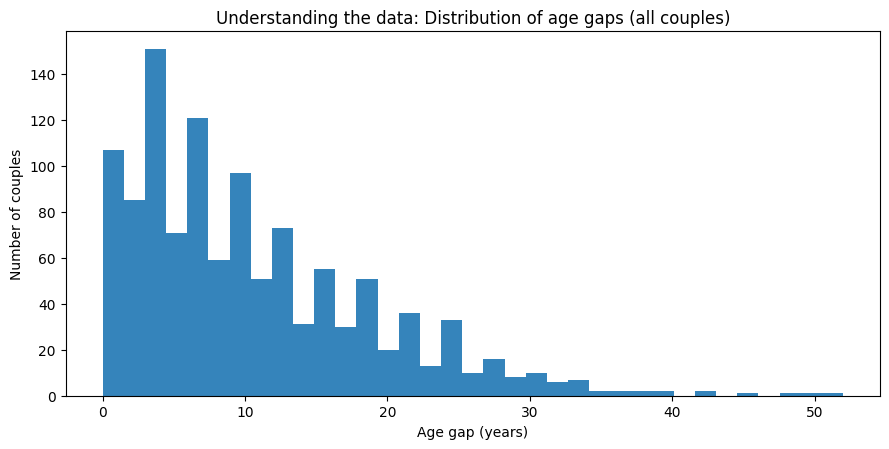

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(age_gap_series, bins=35, alpha=0.90)
ax.set_title("Understanding the data: Distribution of age gaps (all couples)")
ax.set_xlabel("Age gap (years)")
ax.set_ylabel("Number of couples")
plt.tight_layout()
plt.show()

## 3) Boxplot of age_gap (outliers/extreme cases)

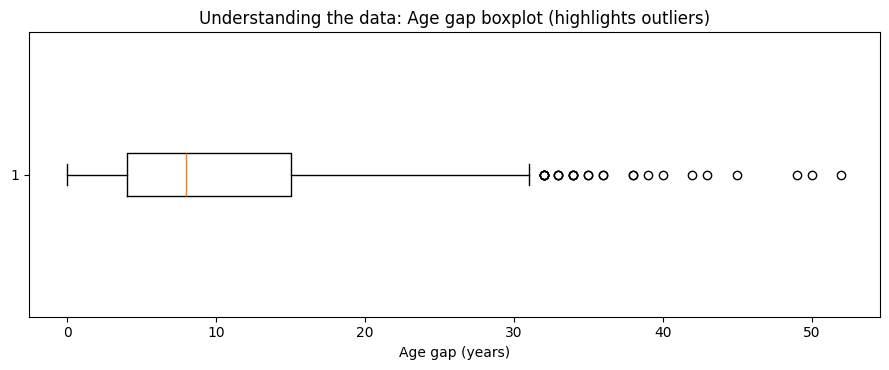

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.boxplot(age_gap_series.values, vert=False, showfliers=True)
ax.set_title("Understanding the data: Age gap boxplot (highlights outliers)")
ax.set_xlabel("Age gap (years)")
plt.tight_layout()
plt.show()

## 4) Release year distribution (data imbalance over time)

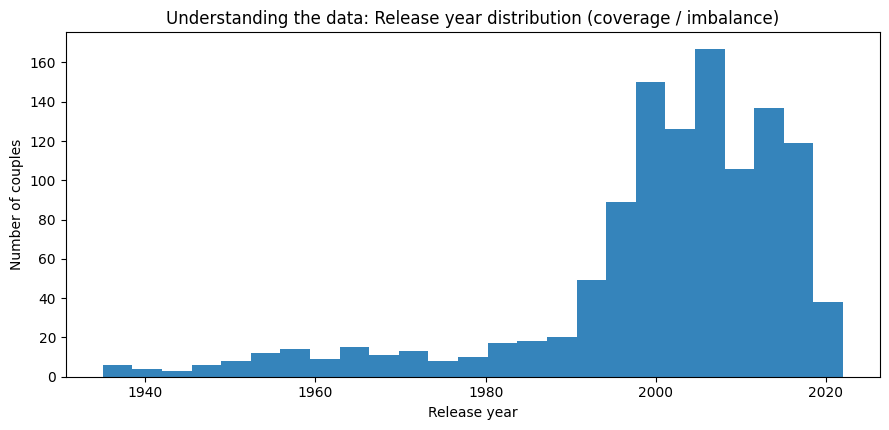

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(df["release_year"], bins=25, alpha=0.90)
ax.set_title("Understanding the data: Release year distribution (coverage / imbalance)")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of couples")
plt.tight_layout()
plt.show()

## 5) Couples per movie (does the dataset contain many multi-couple movies?)

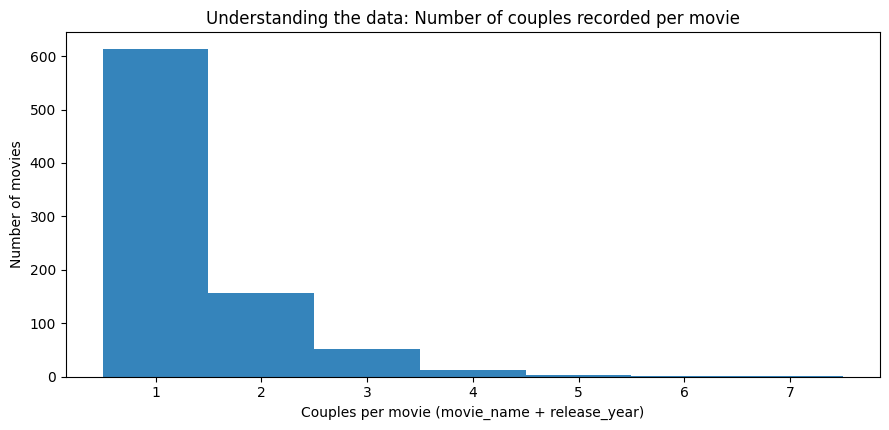

In [7]:
couples_per_movie = df.groupby(movie_key).size()

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(couples_per_movie, bins=range(1, int(couples_per_movie.max()) + 2), alpha=0.90, align="left")
ax.set_title("Understanding the data: Number of couples recorded per movie")
ax.set_xlabel("Couples per movie (movie_name + release_year)")
ax.set_ylabel("Number of movies")
plt.tight_layout()
plt.show()

## 6) Couple-type imbalance (how much is mixed vs same-gender)


Couple type counts (shows representation imbalance):


,pairing_type,count
0,man–woman,929
1,woman–man,203
2,man–man,12
3,woman–woman,11


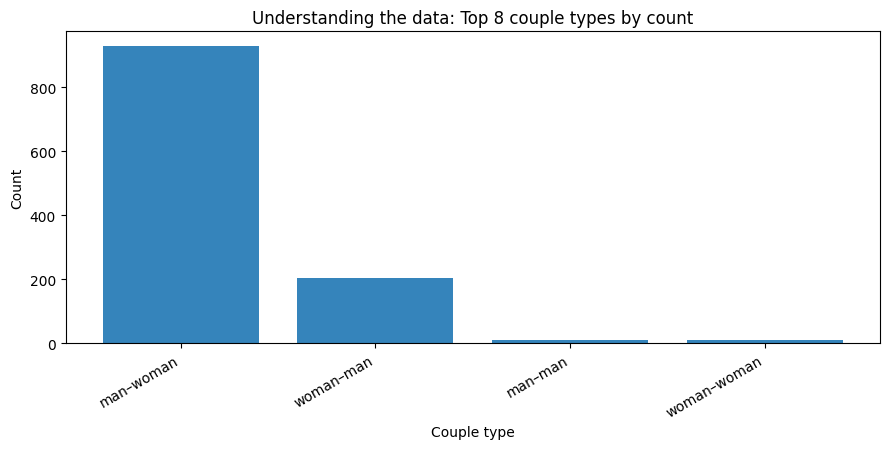

In [8]:
type_counts = (
    df["pairing_type"]
    .value_counts()
    .rename_axis("pairing_type")
    .reset_index(name="count")
)

print("\nCouple type counts (shows representation imbalance):")
display(type_counts)

# Plot the top couple types for readability
top_n = 8
top_types = type_counts.head(top_n)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(top_types["pairing_type"], top_types["count"], alpha=0.90)
ax.set_title(f"Understanding the data: Top {top_n} couple types by count")
ax.set_xlabel("Couple type")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7) Quick check: age_gap vs release_year (scatter only; trend added later in Q1)

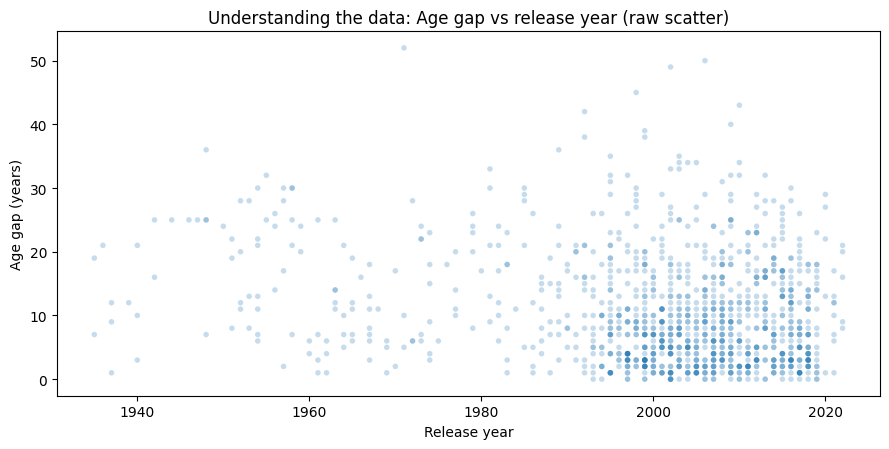

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.scatter(df["release_year"], df["age_gap"], s=16, alpha=0.25, edgecolors="none")
ax.set_title("Understanding the data: Age gap vs release year (raw scatter)")
ax.set_xlabel("Release year")
ax.set_ylabel("Age gap (years)")
plt.tight_layout()
plt.show()

#M2: Director-Level Casting Patterns and Collaboration Structures

In this milestone, we extend the exploratory analysis from M1 by shifting the unit of analysis from individual films to directors. The goal is to examine whether directors with distinct age-gap casting profiles also exhibit persistent collaboration patterns, which may indicate stable creative or casting ecosystems rather than isolated creative choices.

This notebook proceeds in three stages:
1. Exploratory analysis of director coverage and filtering for reliability
2. Construction of director-level age-gap and collaboration features
3. Unsupervised clustering and robustness checks


## 1. Director Coverage and Data Reliability

Before analyzing director behavior, we first examine how many romantic couples are associated with each director. This step is necessary because many directors appear only once or twice in the dataset, making director-level conclusions unreliable.

By inspecting the distribution of couples per director, we can identify whether the data suffers from a long-tail problem and determine an appropriate threshold for inclusion.


Director coverage summary:


,num_couples
count,510.000000
mean,2.264706
std,2.056789
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,20.000000


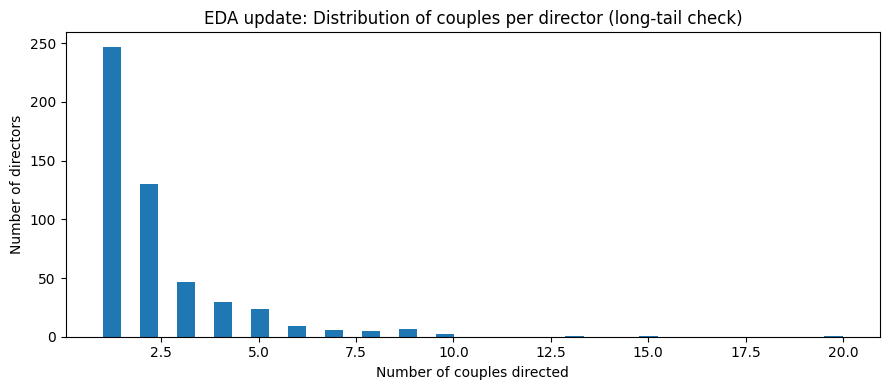

In [10]:
director_counts = (
    df.groupby("director")
      .size()
      .rename("num_couples")
      .sort_values(ascending=False)
)

print("Director coverage summary:")
display(director_counts.describe())

# Visualize long-tail problem
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(director_counts.values, bins=40)
ax.set_title("EDA update: Distribution of couples per director (long-tail check)")
ax.set_xlabel("Number of couples directed")
ax.set_ylabel("Number of directors")
plt.tight_layout()
plt.show()


To reduce noise and ensure that director-level profiles reflect repeated behavior rather than single observations, we restrict the analysis to directors with at least five recorded romantic couples.

This filtering step improves interpretability while retaining a substantial portion of the dataset.


In [11]:
MIN_COUPLES = 5

eligible_directors = director_counts[director_counts >= MIN_COUPLES].index

df_dir = df[df["director"].isin(eligible_directors)].copy()

print(f"Directors retained: {df_dir['director'].nunique()}")
print(f"Couples retained: {len(df_dir)}")

Directors retained: 56
Couples retained: 387


## 2. Director-Level Age-Gap Profiles

Next, we summarize each director’s age-gap behavior using interpretable statistics. These features capture both central tendency and variability, allowing comparison across directors with different casting norms.

The proportion of large age gaps is included to identify directors who consistently cast couples with extreme age differences.


In [12]:
director_age_profile = (
    df_dir
    .groupby("director")
    .agg(
        median_gap=("age_gap", "median"),
        mean_gap=("age_gap", "mean"),
        gap_std=("age_gap", "std"),
        num_couples=("age_gap", "size"),
        pct_large_gap=("is_large_gap", "mean")
    )
    .reset_index()
)

director_age_profile[[
    "median_gap", "mean_gap", "gap_std", "pct_large_gap"
]] = director_age_profile[[
    "median_gap", "mean_gap", "gap_std", "pct_large_gap"
]].round(3)

display(director_age_profile.sort_values("median_gap", ascending=False).head(10))

,director,median_gap,mean_gap,gap_std,num_couples,pct_large_gap
1,Alfred Hitchcock,22.0,21.000,5.228,7,0.857
22,John Huston,21.5,18.500,9.138,6,0.500
20,John Glen,21.0,19.867,7.308,15,0.533
25,Lewis Gilbert,20.0,17.000,6.272,7,0.571
55,Woody Allen,18.5,20.150,11.264,20,0.450
54,Wes Anderson,18.0,13.800,9.094,5,0.400
12,Garry Marshall,18.0,14.800,7.727,5,0.000
14,Guy Hamilton,18.0,16.222,7.311,9,0.444
16,Ivan Reitman,17.0,13.200,10.592,5,0.200
9,David O. Russell,13.0,10.400,6.580,5,0.000


## 3. Collaboration Structure from Actor Name Recurrence

To approximate casting ecosystems, we use actor name repetition as a proxy for collaboration concentration. Directors who repeatedly work with the same actors may operate within more stable or closed creative networks.

We construct collaboration features that summarize how diverse or concentrated each director’s actor pool is.


In [13]:
# Stack actor names into long format
actors_long = pd.concat([
    df_dir[["director", "actor_1_name"]].rename(columns={"actor_1_name": "actor"}),
    df_dir[["director", "actor_2_name"]].rename(columns={"actor_2_name": "actor"})
])

# Actor repetition metrics per director
actor_repeat_stats = (
    actors_long
    .groupby(["director", "actor"])
    .size()
    .rename("collab_count")
    .reset_index()
)

director_actor_stats = (
    actor_repeat_stats
    .groupby("director")
    .agg(
        unique_actors=("actor", "nunique"),
        total_actor_links=("collab_count", "sum"),
        max_actor_repeats=("collab_count", "max")
    )
    .reset_index()
)

display(director_actor_stats.sort_values("max_actor_repeats", ascending=False).head(10))

,director,unique_actors,total_actor_links,max_actor_repeats
20,John Glen,17,30,8
28,Martin Scorsese,17,26,8
49,Terence Young,10,18,8
10,Dennis Dugan,12,18,7
55,Woody Allen,27,40,7
51,Tim Burton,8,12,5
6,Christopher Nolan,9,14,5
14,Guy Hamilton,11,18,5
9,David O. Russell,6,10,4
18,Joe Wright,7,10,4


We now combine age-gap profiles and collaboration features into a single director-level dataset. This table serves as the input for subsequent unsupervised analysis.


In [14]:
director_eda = director_age_profile.merge(
    director_actor_stats,
    on="director",
    how="left"
)

display(director_eda.head())

,director,median_gap,mean_gap,gap_std,num_couples,pct_large_gap,unique_actors,total_actor_links,max_actor_repeats
0,Adrian Lyne,8.5,12.833,13.934,6,0.333,10,12,2
1,Alfred Hitchcock,22.0,21.000,5.228,7,0.857,10,14,3
2,Andy Tennant,6.0,6.800,3.114,5,0.000,9,10,2
3,Ang Lee,2.0,6.286,10.242,7,0.143,12,14,2
4,"Bobby Farrelly, Peter Farrelly",7.0,7.800,4.604,5,0.000,8,10,3


Before clustering, we perform a simple exploratory check to see whether directors with larger typical age gaps also tend to rely more heavily on repeated collaborations.


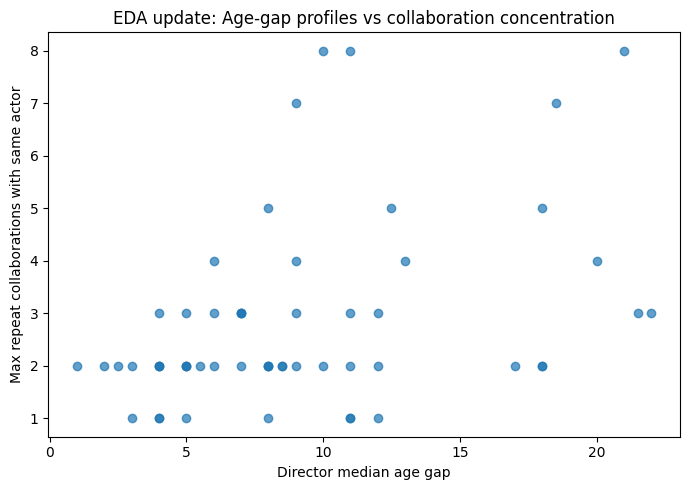

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    director_eda["median_gap"],
    director_eda["max_actor_repeats"],
    alpha=0.7
)
ax.set_xlabel("Director median age gap")
ax.set_ylabel("Max repeat collaborations with same actor")
ax.set_title("EDA update: Age-gap profiles vs collaboration concentration")
plt.tight_layout()
plt.show()

# Unsupervised Analysis: Director Clustering and PCA

We apply unsupervised clustering to examine whether directors form distinct groups based on both age-gap behavior and collaboration structure. The objective is exploratory: to identify latent patterns rather than predict outcomes.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [17]:
# Select director-level features motivated by EDA
feature_cols = [
    "median_gap",
    "gap_std",
    "pct_large_gap",
    "max_actor_repeats",
    "unique_actors"
]

X = director_eda[feature_cols].copy()

# Defensive handling (few directors may have edge cases)
X = X.fillna(0)

# Standardize to prevent scale dominance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


To determine an appropriate number of clusters, we evaluate cluster quality across several values of k using silhouette scores. These scores are used as a diagnostic rather than a strict decision rule.


In [18]:
silhouette_results = {}

for k in range(2, 7):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=25
    )
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_results[k] = sil

silhouette_results

{2: np.float64(0.3605557541520005),
 3: np.float64(0.3153265324283455),
 4: np.float64(0.26472969254111633),
 5: np.float64(0.24602081854038835),
 6: np.float64(0.2806853874530207)}

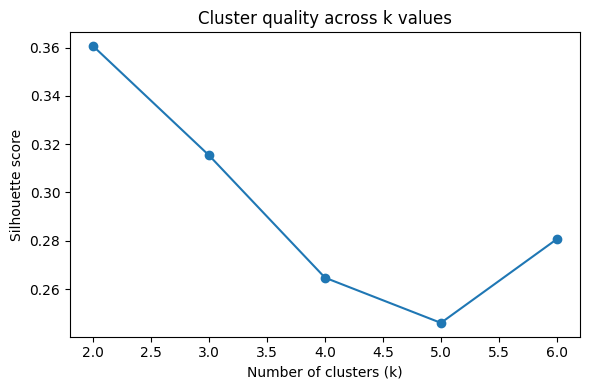

In [19]:
plt.figure(figsize=(6,4))
plt.plot(
    list(silhouette_results.keys()),
    list(silhouette_results.values()),
    marker="o"
)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Cluster quality across k values")
plt.tight_layout()
plt.show()


Based on silhouette scores and interpretability, we select the best-performing k and assign each director to a cluster. We then summarize the characteristics of each cluster.


In [20]:
# Choose k based on silhouette + interpretability
k_final = max(silhouette_results, key=silhouette_results.get)

kmeans = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=25
)

director_eda["cluster"] = kmeans.fit_predict(X_scaled)

director_eda[["director", "cluster"]].head()

,director,cluster
0,Adrian Lyne,0
1,Alfred Hitchcock,0
2,Andy Tennant,1
3,Ang Lee,1
4,"Bobby Farrelly, Peter Farrelly",1


In [21]:
cluster_summary = (
    director_eda
    .groupby("cluster")
    .agg(
        n_directors=("director", "count"),
        median_gap=("median_gap", "mean"),
        gap_std=("gap_std", "mean"),
        pct_large_gap=("pct_large_gap", "mean"),
        max_actor_repeats=("max_actor_repeats", "mean"),
        unique_actors=("unique_actors", "mean")
    )
    .round(3)
)

display(cluster_summary)

,n_directors,median_gap,gap_std,pct_large_gap,max_actor_repeats,unique_actors
cluster,,,,,,
0,15,14.567,10.236,0.401,3.600,12.667
1,41,7.244,6.364,0.078,2.585,10.049


To assess robustness, we repeat the clustering using only age-gap features and compare the resulting cluster assignments. This allows us to evaluate whether collaboration information meaningfully alters group structure.


In [22]:
# Variant: cluster using age-gap features only
age_gap_only_cols = ["median_gap", "gap_std", "pct_large_gap"]

X_gap_only = director_eda[age_gap_only_cols].fillna(0)
X_gap_scaled = scaler.fit_transform(X_gap_only)

km_gap_only = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=25
)

director_eda["cluster_gap_only"] = km_gap_only.fit_predict(X_gap_scaled)

# Compare cluster assignments
comparison = pd.crosstab(
    director_eda["cluster"],
    director_eda["cluster_gap_only"],
    normalize="index"
)

display(comparison)

cluster_gap_only,0,1
cluster,,
0,0.933333,0.066667
1,0.024390,0.975610


Finally, we use principal component analysis (PCA) to visualize cluster separation in two dimensions. PCA is used strictly for interpretation and not for defining cluster membership.


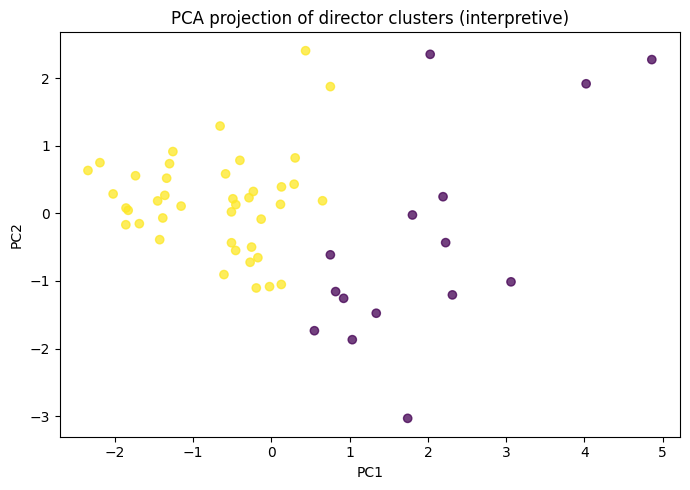

In [23]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

director_eda["pc1"] = X_pca[:, 0]
director_eda["pc2"] = X_pca[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(
    director_eda["pc1"],
    director_eda["pc2"],
    c=director_eda["cluster"],
    alpha=0.75
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of director clusters (interpretive)")
plt.tight_layout()
plt.show()

In [24]:
pd.Series(
    pca.explained_variance_ratio_,
    index=["PC1", "PC2"]
).round(3)

,0
PC1,0.461
PC2,0.217
